In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# simply loads data
def load(fnm):
	return json.load(open(fnm))

def get_choices(data):
    """Pre-Processes Experiment Data

    Returns
        Right choice distance and left choice distance from the entry hole.
        The actual choice made.
        Reaction time.
    """
    choices = []
    for block in data['blocks']:
        trials = block['trials']
        for i, trial in enumerate(trials):
            if i == 0:
                continue
            if 'holes' in trial:
                hole_locs = sorted(trial['holes']['hole_locations'])
            elif 'events' in trial and len(trial['events']) > 0:
                hole_locs = sorted(trial['events'][0]['hole_locations'])
            else:
                print('no choice')
                continue
            if len(hole_locs) == 2:
                if 'holeUsed' in trial:
                    h_cur = trial['holeUsed']
                    h_prev = trials[i-1]['holeUsed']
                elif 'events' in trial and len(trial['events']) > 0 and 'events' in trials[i-1] and len(trials[i-1]['events']) > 0:
                    h_cur = trial['events'][0]['holeUsed']
                    h_prev = trials[i-1]['events'][0]['holeUsed']
                else:
                    continue
                dist_L = np.abs(hole_locs[0] - h_prev)
                dist_R = np.abs(hole_locs[1] - h_prev)
                choice = hole_locs.index(h_cur)
                if 'timePassedThru' in trial:
                    rt = trial['timePassedThru'] - trials[i-1]['timePassedThru']
                elif 'events' in trial and len(trial['events']) > 0 and len(trials[i-1]['events']) > 0:
                    rt = trial['events'][0]['time'] - trials[i-1]['events'][0]['time']
                else:
                    rt = np.nan
                choices.append((dist_L, dist_R, rt, choice))
        return np.vstack(choices)

def compare_greedy_vs_rollout(data, only_use_disagreements=False):
    """Pre-Processes Experiment Data

    Returns
        - Right choice distance and left choice distance from the entry hole.
        - 2-step distances from the beginning of the trial
        - The actual choice made
        - Reaction time: calculated the time passing through the choice level minus the time passing through the entry funnel
    """
    choices = []
    for block in data['blocks']:
        trials = block['trials']
        for i, trial in enumerate(trials):
            if i == 0:
                continue
            if 'holes' in trial:
                hole_locs = sorted(trial['holes']['hole_locations'])
                prev_hole_locs = sorted(trials[i-1]['holes']['hole_locations'])
                next_hole_locs = sorted(trials[i+1]['holes']['hole_locations'])
                h_cur = trial['holeUsed']
                h_prev = trials[i-1]['holeUsed']
                h_next = trials[i+1]['holeUsed']
            elif 'events' in trial and len(trial['events']) > 0 and len(trials[i-1]['events']) > 0 and len(trials[i+1]['events']) > 0:
                hole_locs = sorted(trial['events'][0]['hole_locations'])
                prev_hole_locs = sorted(trials[i-1]['events'][0]['hole_locations'])
                next_hole_locs = sorted(trials[i+1]['events'][0]['hole_locations'])
                h_cur = trial['events'][0]['holeUsed']
                h_prev = trials[i-1]['events'][0]['holeUsed']
                h_next = trials[i+1]['events'][0]['holeUsed']
            else:
                hole_locs = []
                prev_hole_locs = []
                next_hole_locs = []
                h_cur = None
                h_prev = None
            if len(hole_locs) != 2 or len(prev_hole_locs) != 1 or len(next_hole_locs) != 1:
                continue

            dist_L1 = np.abs(hole_locs[0] - h_prev)
            dist_R1 = np.abs(hole_locs[1] - h_prev)
            dist_L2 = dist_L1 + np.abs(hole_locs[0] - h_next)
            dist_R2 = dist_R1 + np.abs(hole_locs[1] - h_next)
            if only_use_disagreements:
                # we ignore trials where both greedy and rollout would make the same choice
                if (dist_L1 < dist_R1 and dist_L2 < dist_R2) or (dist_R1 < dist_L1 and dist_R2 < dist_L2):
                    continue
            
            choice = hole_locs.index(h_cur)
            if 'timePassedThru' in trial:
                rt = trial['timePassedThru'] - trials[i-1]['timePassedThru']
            elif 'events' in trial and len(trial['events']) > 0 and len(trials[i-1]['events']) > 0:
                rt = trial['events'][0]['time'] - trials[i-1]['events'][0]['time']
            else:
                rt = np.nan
            choices.append((dist_L1, dist_R1, dist_L2, dist_R2, rt, choice))
    return np.vstack(choices)

In [10]:
# data analysis block

def plot_psychometric_curve(X, y, fig=None, color='k', xlabel='Δ Distance to hole (L - R)', label='_'):
    """Plots a Psychometric curve

    Inputs:
        - X: difference between the 1-step left distance and 1-step right distance
        - y: the actual choice made

    Returns:
        - A psychometric curve
    """

    xs = np.unique(X)
    ys = []
    ses = []
    for x in xs:
        ix = X == x
        ymu = np.nanmean(y[ix])
        ys.append(ymu)
        ses.append(np.nanstd(y[ix]) / np.sqrt(sum(ix)))

    if fig is None:
        plt.figure(figsize=(3,3), dpi=300)
    for x,y,se in zip(xs,ys,ses):
        plt.plot([x,x],[y-se,y+se],'-', color=color, alpha=0.3)
    plt.plot(xs, ys, '.-', color=color, label=label)
    plt.xlabel(xlabel)
    plt.ylabel('Prob. of choosing Right Hole')
    return fig

def plot_rt_vs_conflict(X, y, fig=None, color='purple', xlabel='Degree of Conflict', label='_'):
    """Raw reaction time vs conflict (probably not helpful because it doesn't take into account the actual time it takes to move)
    """
    
    
    xs = np.unique(X)
    ys = []
    ses = []
    
    for x in xs:
        ix = X == x
        ymu = np.nanmean(y[ix])
        ys.append(ymu)
        ses.append(np.nanstd(y[ix]) / np.sqrt(np.sum(ix)))

    if fig is None:
        fig = plt.figure(figsize=(3,3), dpi=300)
        
    for x, y_val, se in zip(xs, ys, ses):
        plt.plot([x, x], [y_val - se, y_val + se], '-', color=color, alpha=0.3)
        
    plt.plot(xs, ys, '.-', color=color, label=label)
    
    plt.xlabel(xlabel)
    plt.ylabel('Reaction Time (units?)')
    
    if label != '_':
        plt.legend()
        
    return fig

def plot_rt_residuals_vs_conflict(choices, fig=None, rt_regression_type = 'linear'):
    """ Regress residuals against the distance and then plot that against the 'conflict'

    The regression is on the 1-step distance because that's what the reaction time is actually measured against

    Inputs:
        - Take the output of compare_greedy_vs_rollout
        - rt_regression_type determines whether we 'regress' the residuals on distance by taking the linear relationship or by subtracting the minimum amount of time it took to travel that distance

    Outputs:
        - Plots a graph where the y-axis is the residual of the regression, the x-axis is the 'conflict'2-11-trial1.json

    NOTE: I gotta figure out if I'm calculating conflict correctly or not
    """
    # 1. Extract columns from the compare_greedy_vs_rollout output
    # Columns: (dist_L1, dist_R1, dist_L2, dist_R2, rt, choice)
    dist_L1 = choices[:, 0]
    dist_R1 = choices[:, 1]
    dist_L2 = choices[:, 2]
    dist_R2 = choices[:, 3]
    rts = choices[:, 4]
    choice_made = choices[:, 5]

    # Filter out trials with NaN reaction times
    valid_mask = ~np.isnan(rts)
    dist_L1, dist_R1 = dist_L1[valid_mask], dist_R1[valid_mask]
    dist_L2, dist_R2 = dist_L2[valid_mask], dist_R2[valid_mask]
    rts = rts[valid_mask]
    choice_made = choice_made[valid_mask]

    # 2. Identify the total distance traveled over 2-steps based on the user's choice
    chosen_dist_1 = np.where(choice_made == 0, dist_L1, dist_R1)
    predicted_rts = np.zeros(chosen_dist_1.shape)

    # 3. Regress the reaction time vs the chosen 2-step distance
    if rt_regression_type == 'linear':
        slope, intercept = np.polyfit(chosen_dist_1, rts, 1)
        predicted_rts = (slope * chosen_dist_1) + intercept
    elif rt_regression_type == 'minimum':
        unique_distances = np.unique(chosen_dist_1)
        for d in unique_distances:
            idx = chosen_dist_1 == d

            min_rt_for_d = np.min(rts[idx])
            predicted_rts[idx] = min_rt_for_d

    # 4. Collect residuals (Actual RT - Predicted RT)
    residuals = rts - predicted_rts

    # 5. Define Conflict (1-step vs 2-step)
    # Calculated as the difference in magnitude between the 1-step delta and 2-step delta
    conflict_1step = np.abs(dist_L1 - dist_R1)
    conflict_2step = np.abs(dist_L2 - dist_R2)
    conflicts = np.abs(conflict_1step - conflict_2step)
    
    # Round slightly to prevent floating-point precision issues from creating too many bins
    conflicts = np.round(conflicts, decimals=5)
    unique_conflicts = np.unique(conflicts)

    if fig is None:
        fig = plt.figure(figsize=(8, 5), dpi=300)

    # Plot raw trial residuals in the background
    plt.scatter(conflicts, residuals, alpha=0.2, color='gray', label='Trial Residuals')

    # Calculate and plot mean residuals (with standard error) for each conflict level
    mean_residuals = []
    ses = []
    
    for c in unique_conflicts:
        ix = conflicts == c
        res_c = residuals[ix]
        
        mean_val = np.mean(res_c)
        se_val = np.std(res_c) / np.sqrt(len(res_c)) if len(res_c) > 0 else 0
        
        mean_residuals.append(mean_val)
        ses.append(se_val)
        
        # Error bar
        plt.plot([c, c], [mean_val - se_val, mean_val + se_val], '-', color='blue', alpha=0.7)

    # Line connecting the means
    plt.plot(unique_conflicts, mean_residuals, 'o-', color='blue', linewidth=2, markersize=6, label='Mean Residual')

    # Baseline at 0 (representing the exact regression prediction)
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Expected RT (Baseline)')

    # Labels and Formatting
    plt.xlabel('Conflict Margin (|1-Step Diff - 2-Step Diff|)')
    plt.ylabel('Reaction Time Residual (ms)')
    plt.title('RT Residuals (Controlling for 2-Step Distance) vs. Conflict')
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.close(fig)
    
    return fig

def plot_rt_over_time_by_conflict(trial_nums, conflicts, rts, window_size=10, fig=None):
    """
    Similarly obsolete as the previous plot_rt_vs_conflict function 
    """
    
    
    sort_idx = np.argsort(trial_nums)
    c_sorted = conflicts[sort_idx]
    rt_sorted = rts[sort_idx]

    unique_conflicts = np.unique(c_sorted)

    if fig is None:
        fig = plt.figure(figsize=(8, 5), dpi=300)

    for c in unique_conflicts:
        ix = c_sorted == c
        rt_c = rt_sorted[ix]
        
        local_trials = np.arange(1, len(rt_c) + 1)
        
        if len(rt_c) >= window_size:
            moving_avg = np.convolve(rt_c, np.ones(window_size)/window_size, mode='valid')
            t_moving_avg = local_trials[window_size - 1:]
            
            plt.plot(t_moving_avg, moving_avg, linewidth=2.5, linestyle='-', label=f'Conflict: {c:.2f}')

    plt.xlabel('Trial Number')
    plt.ylabel('Reaction Time (units?)')
    plt.title(f'(Rxn time by conflict)')
    
    # Place legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    return fig

def plot_rt_residuals_over_time(choices, window_size=10, fig=None, rt_regression_type = 'linear'):
    """The 'residuals' of the reaction time plotted over time as a moving average

    Inputs:
        - Takes the output of compare_greedy_vs_rollout for 'choices'
        - The window size determines the moving average
        - rt_regression_type is 'linear' if we want to calculate the predicted residuals via linear regression, or 'minimum' if we want to compare against the minimum amount of time taken to move 

    Outputs:
        - Moving average plot of reaction times over expeceted reaction time, separated by the 'degree of conflict'2-11-trial1.json

    NOTE: Is it valid to plot moving averages like this?
    """
    
    # 1. Extract columns from the compare_greedy_vs_rollout output
    dist_L1 = choices[:, 0]
    dist_R1 = choices[:, 1]
    dist_L2 = choices[:, 2]
    dist_R2 = choices[:, 3]
    rts = choices[:, 4]
    choice_made = choices[:, 5]

    # Filter out trials with NaN reaction times
    valid_mask = ~np.isnan(rts)
    dist_L1, dist_R1 = dist_L1[valid_mask], dist_R1[valid_mask]
    dist_L2, dist_R2 = dist_L2[valid_mask], dist_R2[valid_mask]
    rts = rts[valid_mask]
    choice_made = choice_made[valid_mask]

    # 2. Regress RT vs the chosen 2-step distance to get residuals
    chosen_dist_1 = np.where(choice_made == 0, dist_L1, dist_R1)
    slope, intercept = np.polyfit(chosen_dist_1, rts, 1)

    predicted_rts = np.zeros_like(rts)

    if rt_regression_type == 'linear':
        slope, intercept = np.polyfit(chosen_dist_1, rts, 1)
        predicted_rts = (slope * chosen_dist_1) + intercept
    elif rt_regression_type == 'minimum':
        unique_distances = np.unique(chosen_dist_1)
        for d in unique_distances:
            idx = chosen_dist_1 == d

            min_rt_for_d = np.min(rts[idx])
            predicted_rts[idx] = min_rt_for_d

    residuals = rts - predicted_rts

    # 3. Define Conflict (1-step vs 2-step)
    conflict_1step = np.abs(dist_L1 - dist_R1)
    conflict_2step = np.abs(dist_L2 - dist_R2)
    conflicts = np.abs(conflict_1step - conflict_2step)
    
    # Round slightly to group similar conflict levels
    conflicts = np.round(conflicts, decimals=5)
    unique_conflicts = np.unique(conflicts)

    if fig is None:
        fig = plt.figure(figsize=(8, 5), dpi=300)

    # Add a baseline at 0 to show the "expected" reaction time
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Expected RT (0 Residual)')

    # 4. Plot moving average for each degree of conflict independently
    for c in unique_conflicts:
        ix = conflicts == c
        res_c = residuals[ix]
        
        # Because we read the array top-to-bottom, the data is naturally chronological.
        # We just count the local encounters for this specific conflict.
        local_trials = np.arange(1, len(res_c) + 1)
        
        # Calculate and plot the moving average trendline
        if len(res_c) >= window_size:
            moving_avg = np.convolve(res_c, np.ones(window_size)/window_size, mode='valid')
            t_moving_avg = local_trials[window_size - 1:]
            
            plt.plot(t_moving_avg, moving_avg, linewidth=2.5, linestyle='-', label=f'Conflict: {c:.2f}')

    # Labels and Formatting
    plt.xlabel('Number of Encounters (Local Trial Count)')
    plt.ylabel('Reaction Time Residual (ms)')
    plt.title(f'RT Residuals by Conflict Exposure ({window_size}-Trial Moving Avg)')
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    plt.close(fig)
    
    return fig

def plot_rt_vs_distance(choices, step=1):
    dist_L1 = choices[:, 0]
    dist_R1 = choices[:, 1]
    dist_L2 = choices[:, 2]
    dist_R2 = choices[:, 3]
    rt = choices[:, 4]
    choice_made = choices[:, 5]

    valid_mask = rt>0
    
    if step == 1:
        chosen_dist = np.where(choice_made == 0, dist_L1, dist_R1)
        xlabel = '1-Step Distance Traveled'
    elif step == 2:
        chosen_dist = np.where(choice_made == 0, dist_L2, dist_R2)
        xlabel = 'Total 2-Step Path Distance'
    else:
        raise ValueError("The 'step' parameter must be 1 or 2.")

    x_data = chosen_dist[valid_mask]
    y_data = rt[valid_mask]
    choices_valid = choice_made[valid_mask]

    fig = plt.figure(figsize=(7, 5), dpi=300)
    
    idx_L = choices_valid == 0
    idx_R = choices_valid == 1
    
    plt.scatter(x_data[idx_L], y_data[idx_L], alpha=0.4, label='Chose Left', color='blue')
    plt.scatter(x_data[idx_R], y_data[idx_R], alpha=0.4, label='Chose Right', color='orange')
    
    plt.xlabel(xlabel)
    plt.ylabel('Reaction Time (ms)')
    plt.title(f'Reaction Time vs. {xlabel}')
    plt.legend()
    plt.tight_layout()
    
    return fig

def plot_conflict_vs_rt_heatmap(choices, rt_regression_type='linear'):
    dist_L1 = choices[:, 0]
    dist_R1 = choices[:, 1]
    dist_L2 = choices[:, 2]
    dist_R2 = choices[:, 3]
    rts = choices[:, 4]
    choice_made = choices[:, 5]

    conflict_1step = dist_L1 - dist_R1
    conflict_2step = dist_L2 - dist_R2

    chosen_dist_1 = np.where(choice_made == 0, dist_L1, dist_R1)
    
    predicted_rts = np.zeros_like(rts)

    if rt_regression_type == 'linear':
        slope, intercept = np.polyfit(chosen_dist_1, rts, 1)
        predicted_rts = (slope * chosen_dist_1) + intercept
    elif rt_regression_type == 'minimum':
        unique_distances = np.unique(chosen_dist_1)
        for d in unique_distances:
            idx = chosen_dist_1 == d
            min_rt_for_d = np.min(rts[idx])
            predicted_rts[idx] = min_rt_for_d

    residuals = rts - predicted_rts

    unique_1step_conflicts = np.sort(np.unique(conflict_1step))
    unique_2step_conflicts = np.sort(np.unique(conflict_2step))

    rt_heatmap = np.zeros((unique_1step_conflicts.size, unique_2step_conflicts.size))

    for r_idx, val_1step in enumerate(unique_1step_conflicts):
        for c_idx, val_2step in enumerate(unique_2step_conflicts):
            
            idx = (conflict_1step == val_1step) & (conflict_2step == val_2step)
            
            if np.sum(idx) > 0:
                rt_heatmap[r_idx, c_idx] = np.mean(residuals[idx])
            else:
                rt_heatmap[r_idx, c_idx] = np.nan

    fig, ax = plt.subplots(figsize=(8, 6))
    
    im = ax.imshow(rt_heatmap, origin='lower', cmap='viridis')
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Mean RT Residual", rotation=-90, va="bottom")

    ax.set_xticks(range(len(unique_2step_conflicts)))
    ax.set_xticklabels(np.round(unique_2step_conflicts, 2), rotation=45)
    ax.set_xlabel('2-Step Conflict (L2-R2)')

    ax.set_yticks(range(len(unique_1step_conflicts)))
    ax.set_yticklabels(np.round(unique_1step_conflicts, 2))
    ax.set_ylabel('1-Step Conflict (L1-R1)')

    ax.set_title("RT Residuals by 1-Step and 2-Step Conflict")
    
    fig.tight_layout()
    plt.show()
            

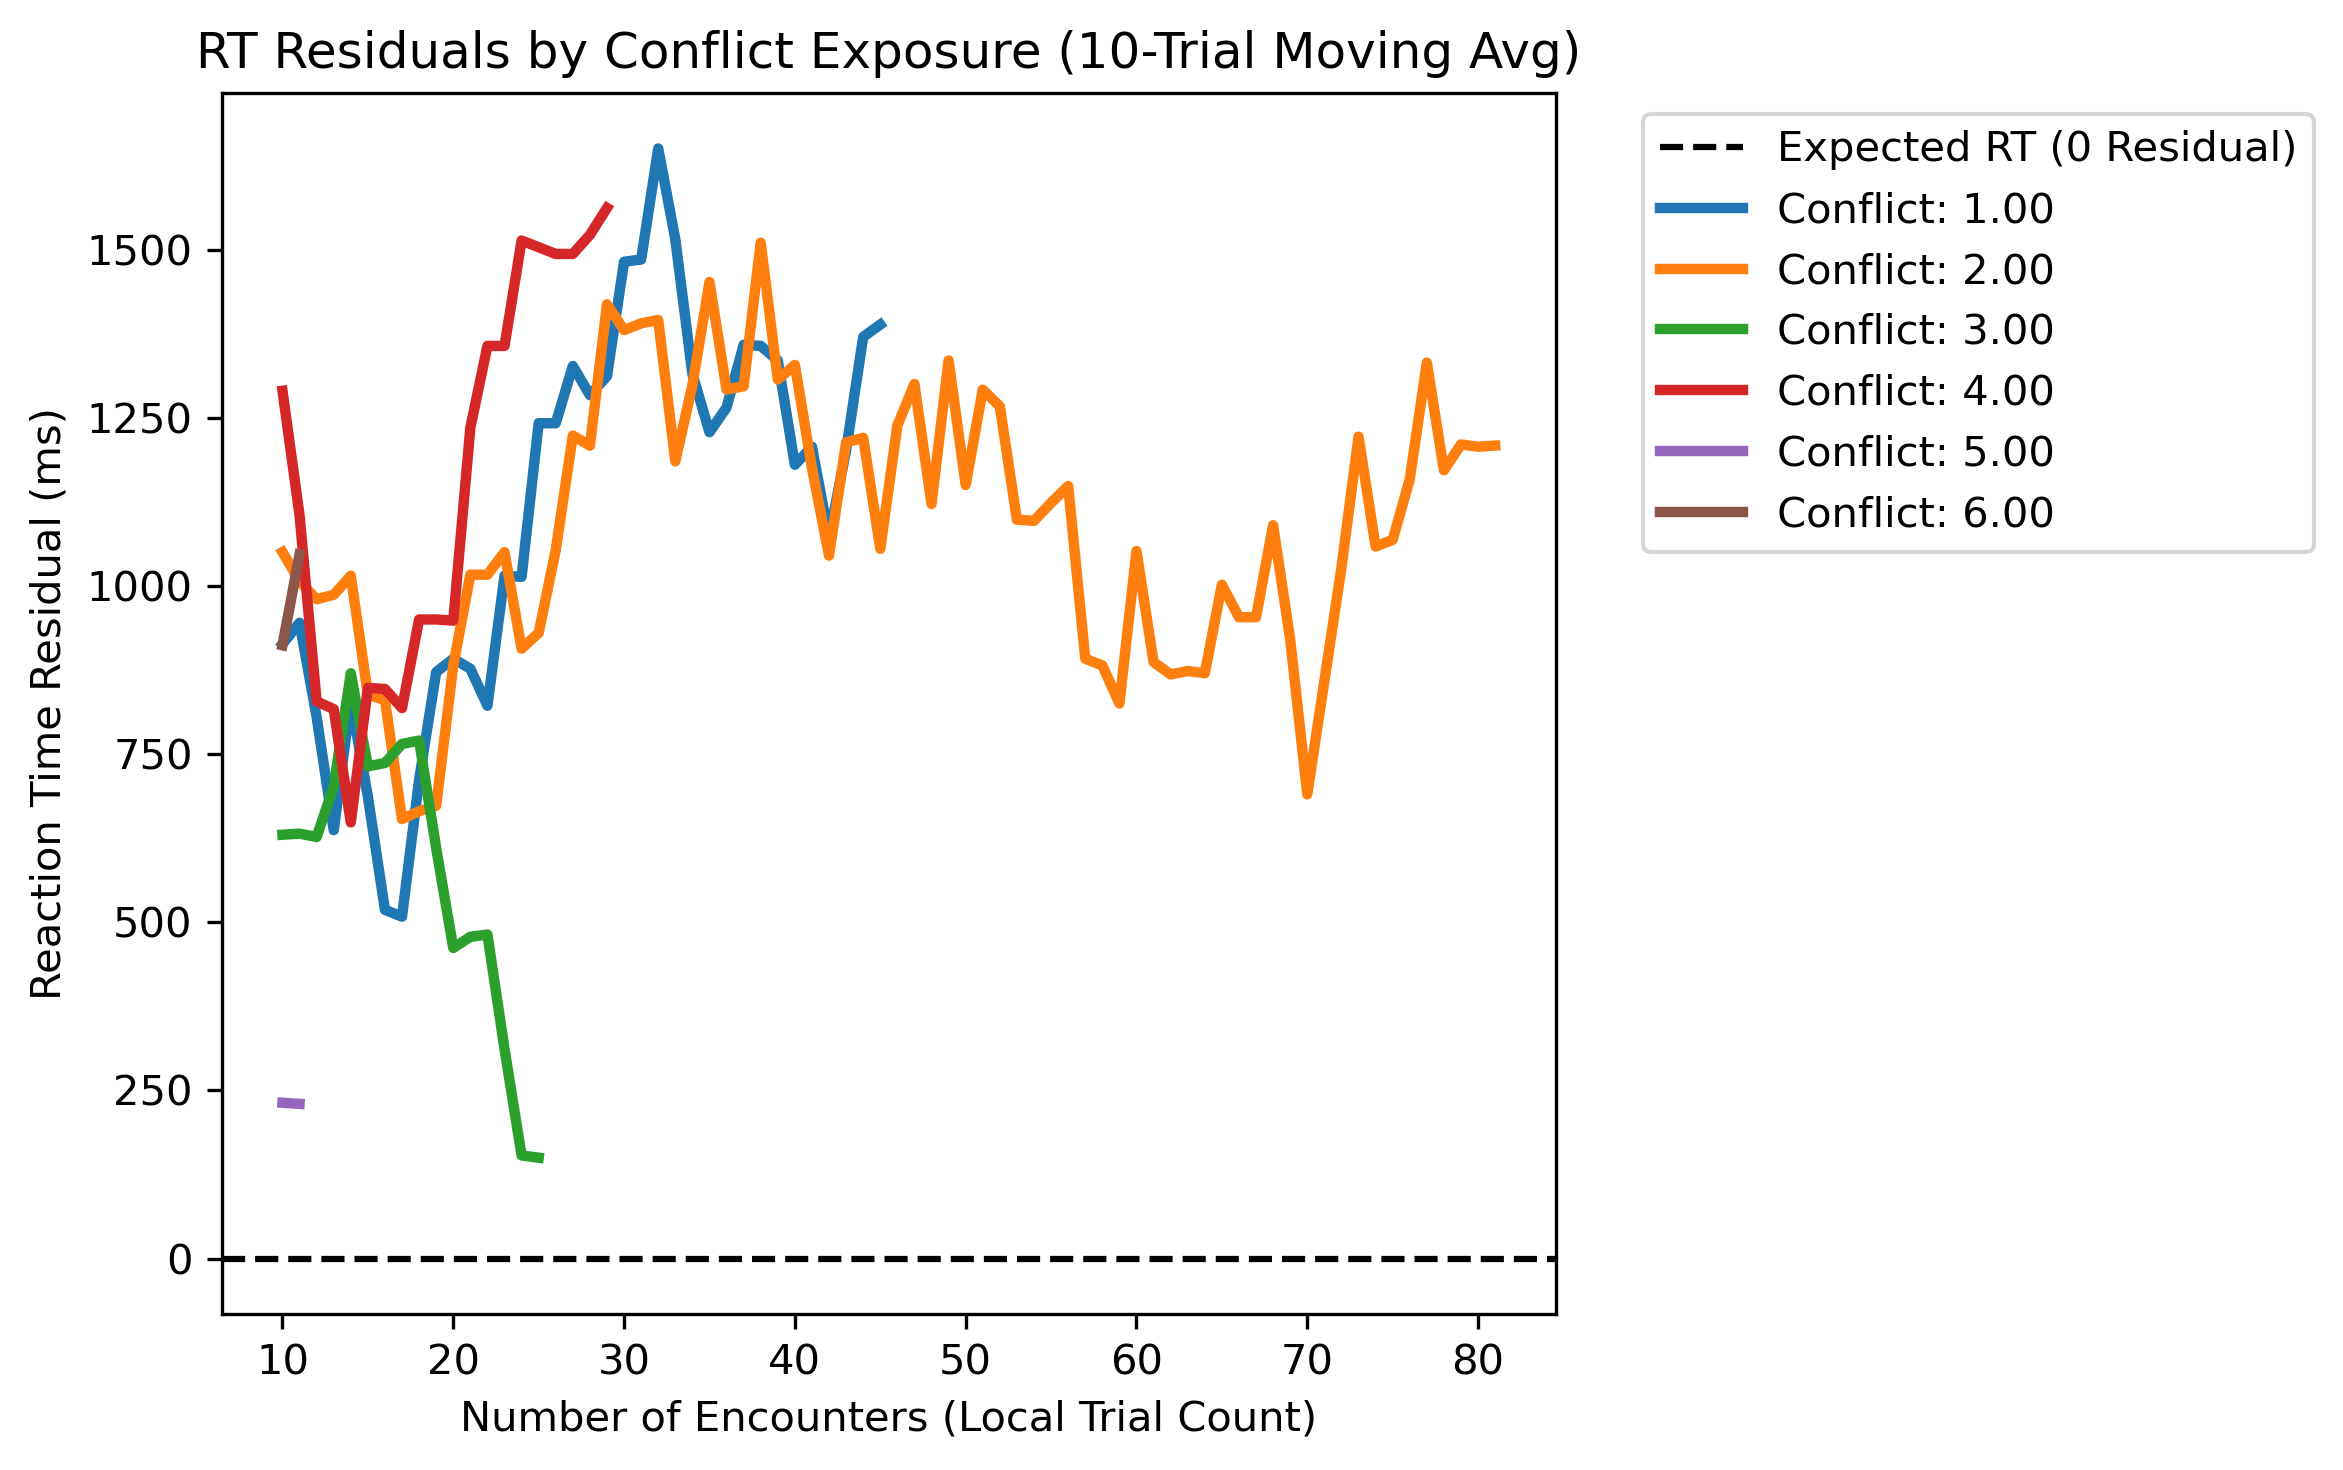

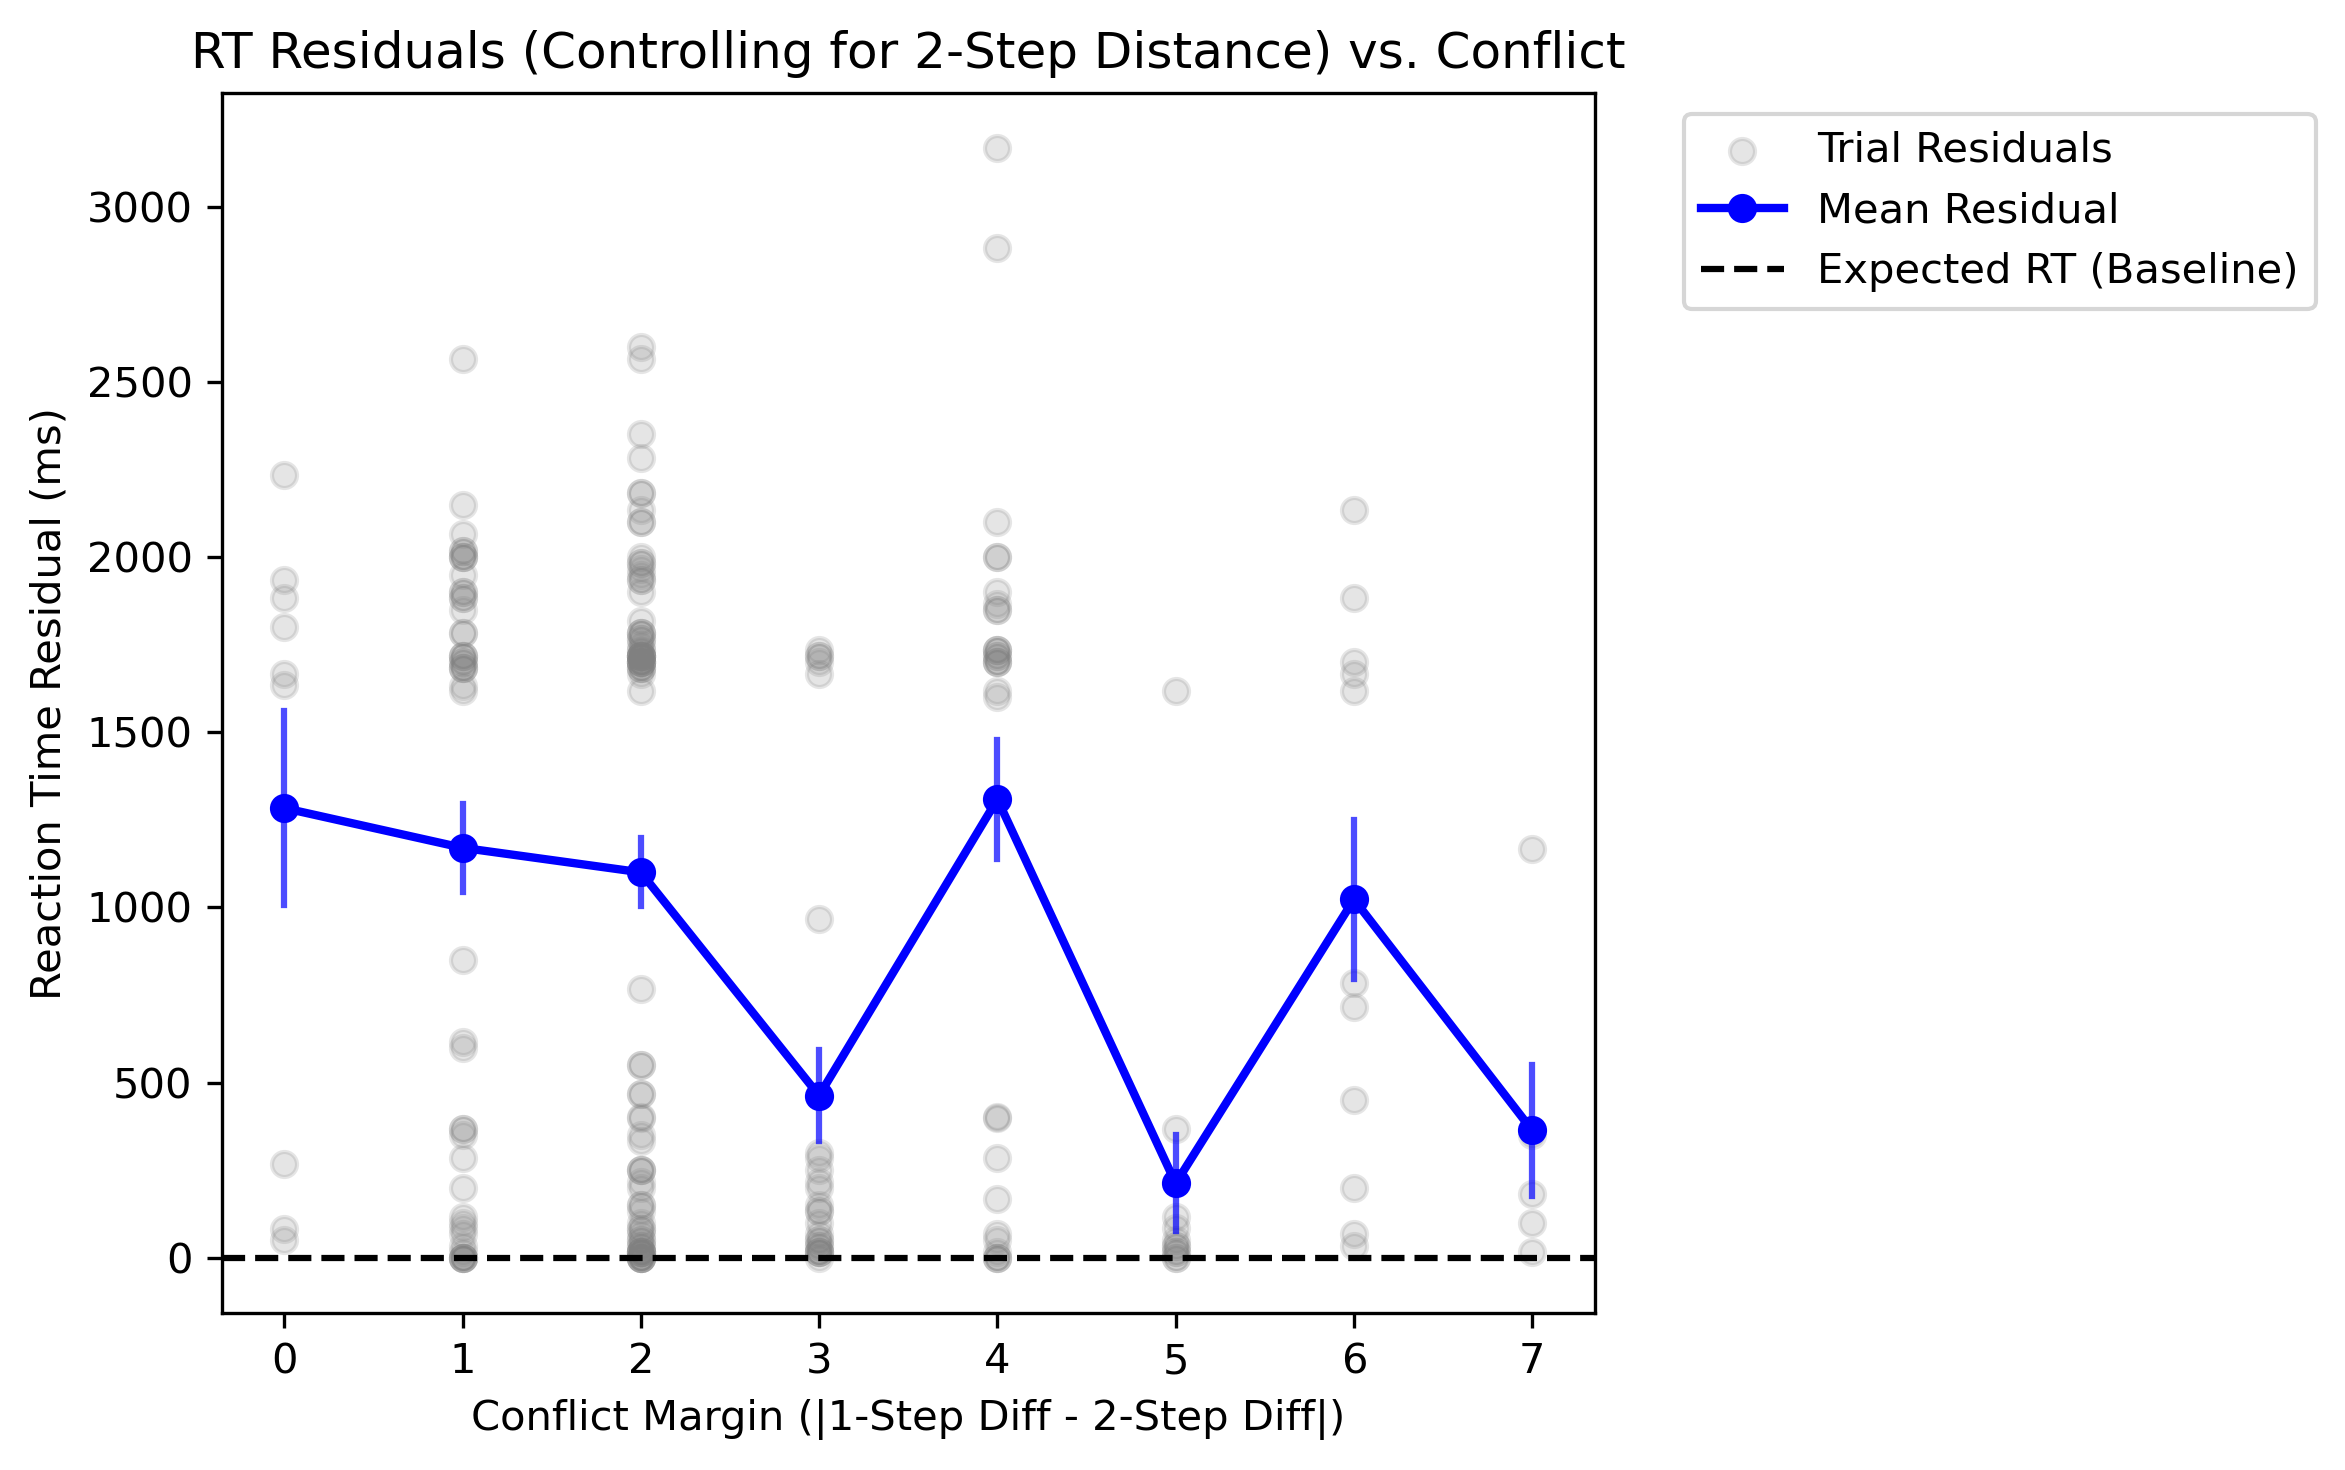

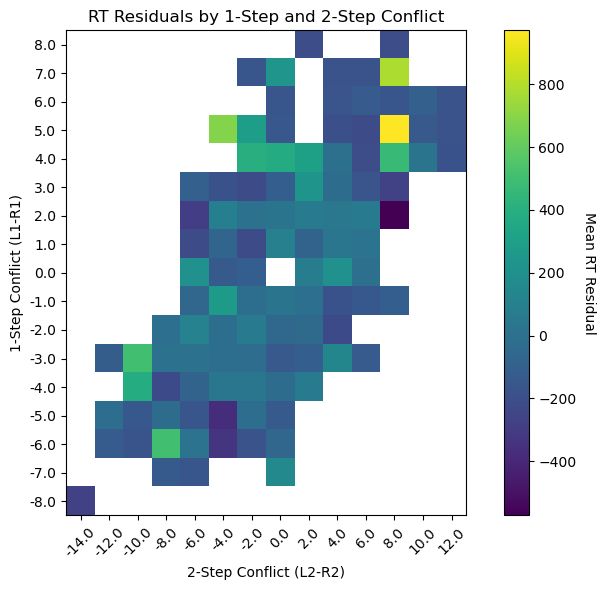

In [11]:
data = load("real_trial1.json")

choices = compare_greedy_vs_rollout(data, only_use_disagreements=True)

#plot_rt_residuals_vs_conflict(choices)
rt_over_time_minimum_30 = plot_rt_residuals_over_time(choices, window_size= 10, rt_regression_type= 'minimum')
display(rt_over_time_minimum_30)

rt_vs_conflict_minimum = plot_rt_residuals_vs_conflict(choices, rt_regression_type= 'minimum')
display(rt_vs_conflict_minimum)

choices = compare_greedy_vs_rollout(data, only_use_disagreements=False)
plot_conflict_vs_rt_heatmap(choices)

In [ ]:
choices = 